# Row 8: Next-day range by the sign of GEX at the close

| field | content |
|---|---|
| frequency (GEX period) | daily print |
| strength | 0.52 Spearman correlation |
| tradability (1 to 10) | 6 |
| holds for | yes SPY, QQQ (1.13% versus 1.61%, correlation -0.39), IWM (correlation -0.20), AAPL (own tercile 1.78% versus 2.28%), MSFT (2.05% versus 2.40%); weak AMZN, META; no NVDA, TSLA, AMD. Stocks need the own-tercile cut because they are rarely negative |
| how to trade | next-day volatility filter: short gamma and tighter stops after a positive close, long gamma and wider stops after a negative one |
| numbers (SPY) | range 0.75% versus 1.22%, absolute move 0.46% versus 0.80%, p-value below 0.001 |
| example | 2026-08-13 +19.5 billion dollars, next-day range 0.43% (median day 0.85%); 2026-03-19 -19.3 billion, next-day range 1.81% |
| video opener | When option dealers are long gamma they sell rallies and buy dips to stay hedged, and the market moves less; when they are short gamma they do the opposite and moves get amplified. You can read which state they are in from the day's option data, and it predicts tomorrow's trading range well enough to decide tonight whether to sell options or buy them. |

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy")
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


,n_pos,n_neg,mean_pos,mean_neg,median_pos,median_neg,diff,ci_lo,ci_hi,p_mwu,expectation,verdict
test,,,,,,,,,,,,
range,316,434,0.0075,0.0122,0.0068,0.0106,-0.0047,-0.0057,-0.0039,0.0,lower in +GEX,supported
move,316,434,0.0046,0.0080,0.0035,0.0063,-0.0034,-0.0043,-0.0025,0.0,lower in +GEX,supported


{
 "tercile_range_next": {
  "bottom third": 0.013873386896623397,
  "top third": 0.007289535807918157,
  "p": 2.1972719693740855e-38
 },
 "spearman_gex_next_range": -0.5182673320308124
}


k,-5,-4,-3,-2,-1,0,1,2,3,4,5
pearson,-0.181,-0.212,-0.235,-0.252,-0.308,-0.397,-0.388,-0.363,-0.330,-0.284,-0.246
spearman,-0.168,-0.217,-0.268,-0.297,-0.369,-0.513,-0.518,-0.471,-0.403,-0.324,-0.284
n,751.000,751.000,751.000,751.000,751.000,751.000,750.000,749.000,748.000,747.000,746.000


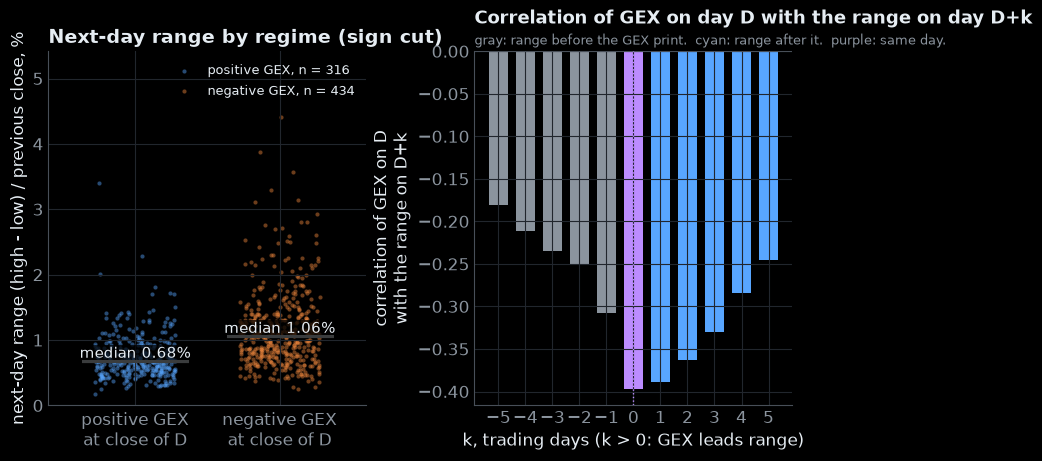

In [2]:
res = R.row8(ctx)
display(res['sign_cut'].drop(columns=['outcome']).round(4))
print(json.dumps({k: v for k, v in R.show(res).items() if k not in ('sign_cut', 'cross_correlation')}, indent=1))
display(res['cross_correlation'].T.round(3))
_ = R.fig8(ctx, res, G.FIGURES / 'row08_next_day_range.png')

The first two panels show daily candles around the single most positive and the single most negative gamma closes in the sample; the shaded candle is the following day and the text gives its high-to-low range. The right panel is the average next-day range over all days, split by whether the close before it was positive or negative.

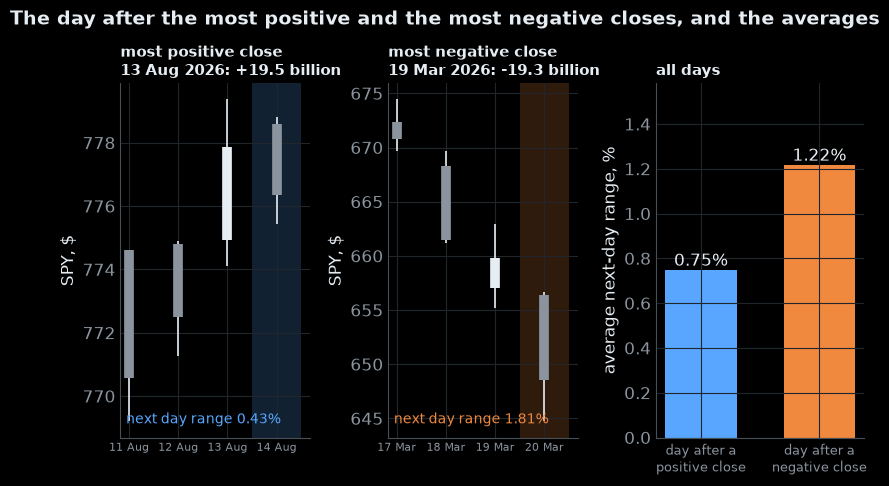

In [3]:
_ = R.fig_open8(ctx, res, G.FIGURES / 'row08_opener.png')

In [4]:
R.per_name({'r8_range_pos': 'next-day range after a positive close', 'r8_range_neg': 'after a negative close', 'r8_n_neg': 'negative days', 'r8_range_top_third': 'own top third', 'r8_range_bottom_third': 'own bottom third', 'r8_p_tercile': 'p-value (terciles)', 'r8_spearman_gex_next_range': 'Spearman correlation'}).round(3)

,next-day range after a positive close,after a negative close,negative days,own top third,own bottom third,p-value (terciles),Spearman correlation
symbol,,,,,,,
SPY,0.007,0.012,435,0.007,0.014,0.000,-0.518
QQQ,0.011,0.016,148,0.011,0.017,0.000,-0.390
IWM,0.014,0.016,205,0.013,0.017,0.003,-0.198
NVDA,0.030,0.035,13,0.029,0.032,0.210,-0.095
TSLA,0.036,0.040,51,0.037,0.038,0.478,-0.047
AAPL,0.021,0.022,6,0.018,0.023,0.000,-0.193
AMZN,0.024,0.026,10,0.023,0.026,0.096,-0.141
META,0.026,0.028,74,0.025,0.028,0.044,-0.142
MSFT,0.021,0.024,48,0.021,0.024,0.018,-0.147
